In [6]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [9]:
# Load data 
df = pd.read_csv("../Modified_Pupilometri/pupilometry_features_right_noCHerror.csv")
df = df[df["redcap_repeat_instance"] == 1]
df_t50 = pd.read_csv("../R_attempt/df_T50.csv")
df_t50['record_id'] = df_t50['pt_id'].str.replace('S_', '', regex=False)
df_t50['record_id'] = df_t50['record_id'].astype(int)
df_t50['redcap_repeat_instance'] = df_t50['day']
df_t50['eye'] = df_t50['lateral']
df = df.merge(
    df_t50,
    on=['record_id', 'redcap_repeat_instance', 'eye'],
    how='left'
)

In [10]:
#Define features used
feature_cols = [
    "pupil_size",
    "pupil_min",
    "ch",
    "const_velocity",
    "dilat_velocity",
    "max_const_velocity",
    "latency",
    "npi",
    "LOR_early_gradient",
    "LOR_late_gradient",
    "pupil_dilation",
    "T50_dilat"
]

NPI_features = [
    "pupil_size",
    "pupil_min",
    "ch",
    "const_velocity",
    "dilat_velocity",
    "max_const_velocity",
    "latency"
]

df = df[feature_cols].dropna()
df_npi = df[NPI_features].dropna()

Explained variance ratio: [0.50477758 0.1981402  0.08696251 0.07801265 0.0681184  0.0248463
 0.01783995 0.01046792 0.00596912 0.00219051 0.00212248 0.00055238]
Principal components shape: (233, 12)


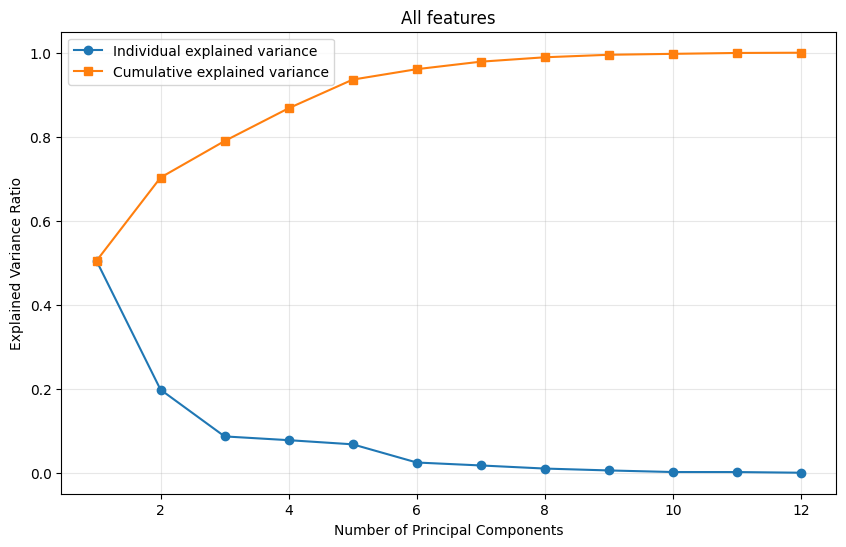

In [11]:
# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Apply PCA
pca = PCA(n_components=12)
principal_components = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Principal components shape:", principal_components.shape)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10,6))

# Individual explained variance
plt.plot(range(1, len(explained_variance)+1),
         explained_variance,
         marker='o',
         label='Individual explained variance')

# Cumulative explained variance
plt.plot(range(1, len(cumulative_variance)+1),
         cumulative_variance,
         marker='s',
         label='Cumulative explained variance')

plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('All features')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


In [12]:
#Get loadings
loadings = pd.DataFrame(
    pca.components_.T,      
    index=df.columns,       
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

Explained variance ratio: [0.60252442 0.21349528 0.1314633  0.03464989 0.01227149 0.00445575
 0.00113987]
Principal components shape: (233, 7)


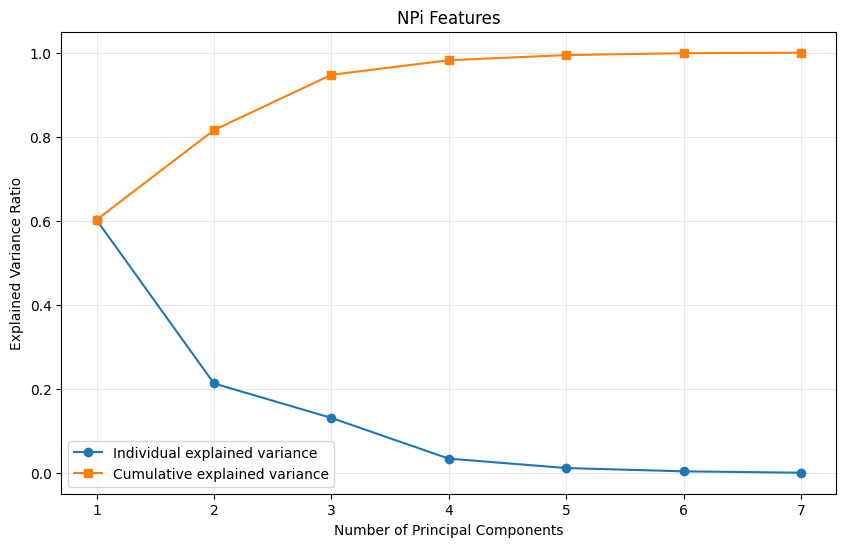

In [13]:
# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_npi)

# Apply PCA
pca = PCA(n_components=7)
principal_components = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Principal components shape:", principal_components.shape)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10,6))

# Individual explained variance
plt.plot(range(1, len(explained_variance)+1),
         explained_variance,
         marker='o',
         label='Individual explained variance')

# Cumulative explained variance
plt.plot(range(1, len(cumulative_variance)+1),
         cumulative_variance,
         marker='s',
         label='Cumulative explained variance')

plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('NPi Features')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


In [14]:
#Get loadings
NPI_loadings = pd.DataFrame(
    pca.components_.T,        # shape (10,39)
    index=df_npi.columns,       
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

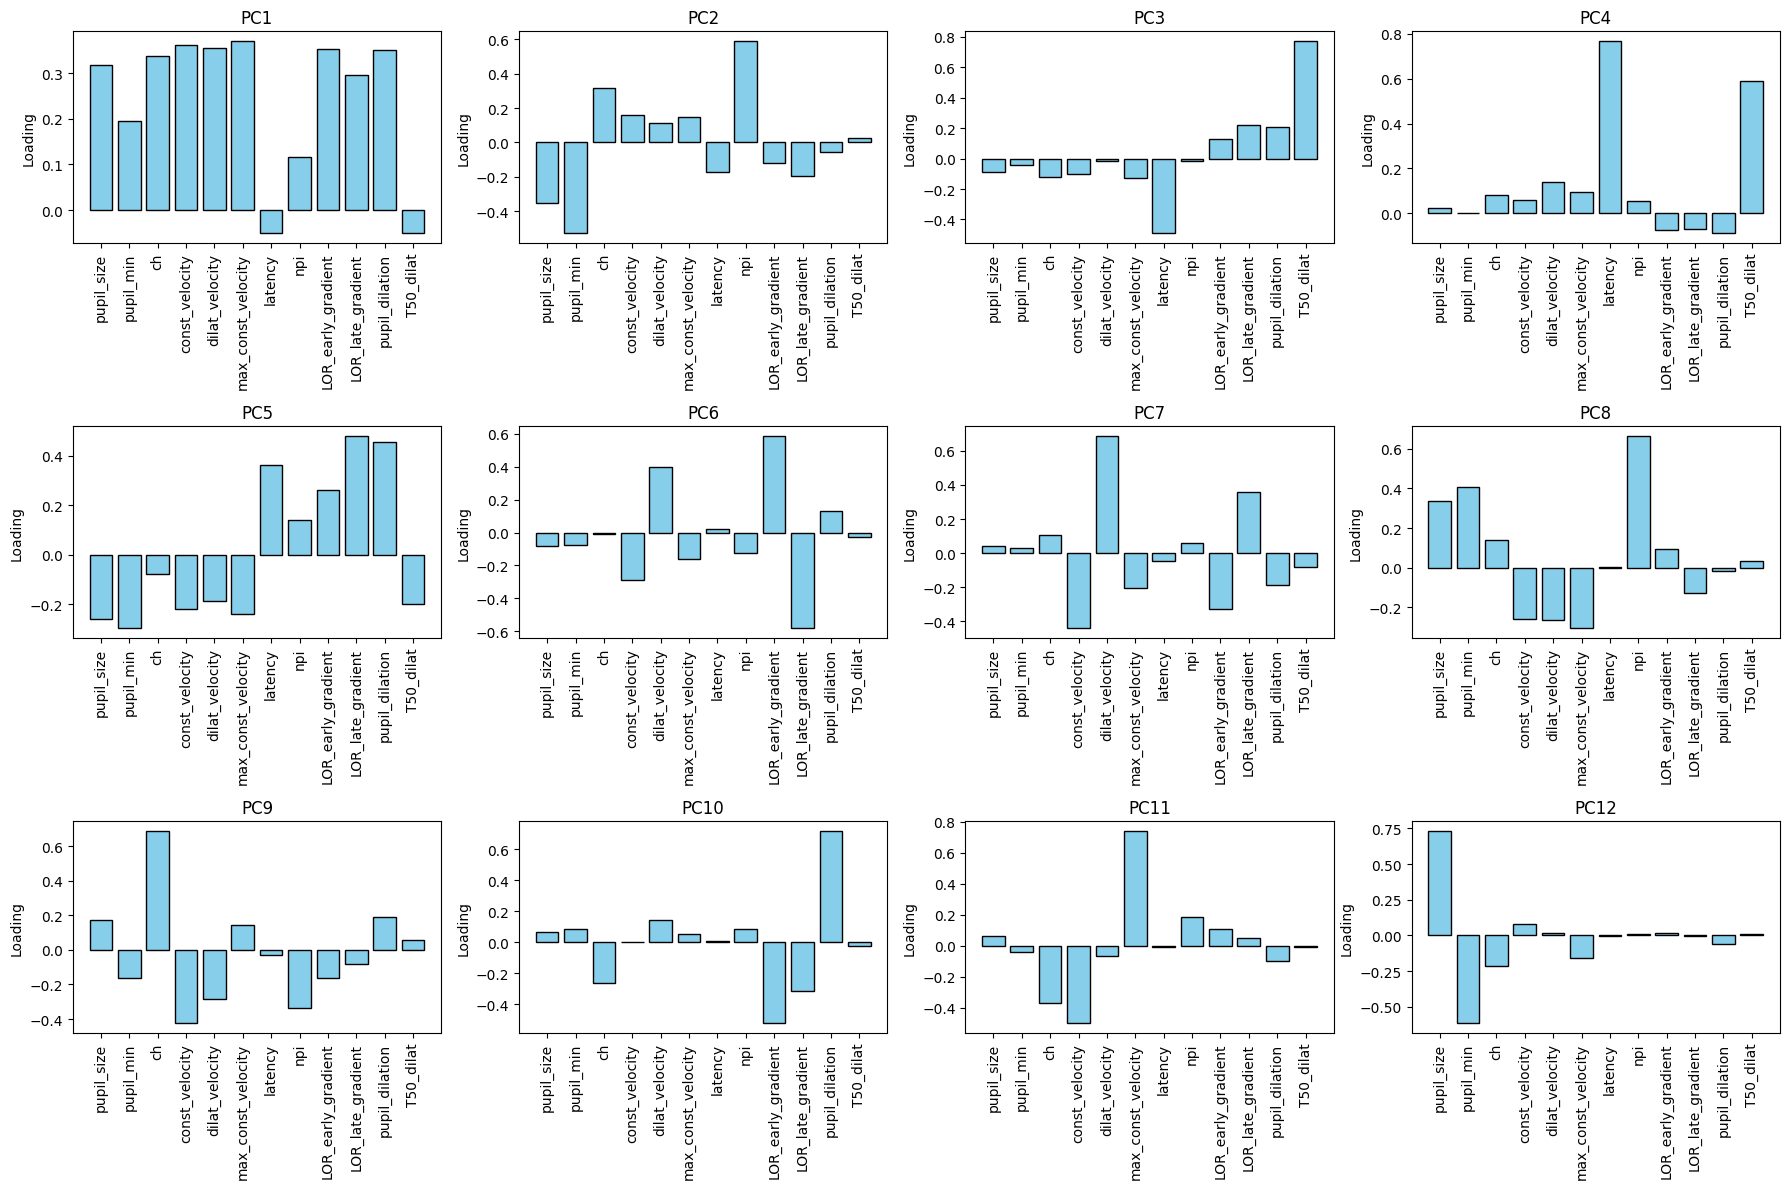

In [15]:
# Number of PCs to plot for all features
n_pcs = 12
pcs_to_plot = [f"PC{i+1}" for i in range(n_pcs)]

plt.figure(figsize=(18, 12))

for i, pc in enumerate(pcs_to_plot, 1):
    plt.subplot(3, 4,i)  # 2 rows, 3 columns of subplots
    plt.bar(df.columns, loadings[pc], color='skyblue', edgecolor='black')
    plt.xticks(rotation=90)
    plt.ylabel("Loading")
    plt.title(pc)

plt.tight_layout()
plt.show()

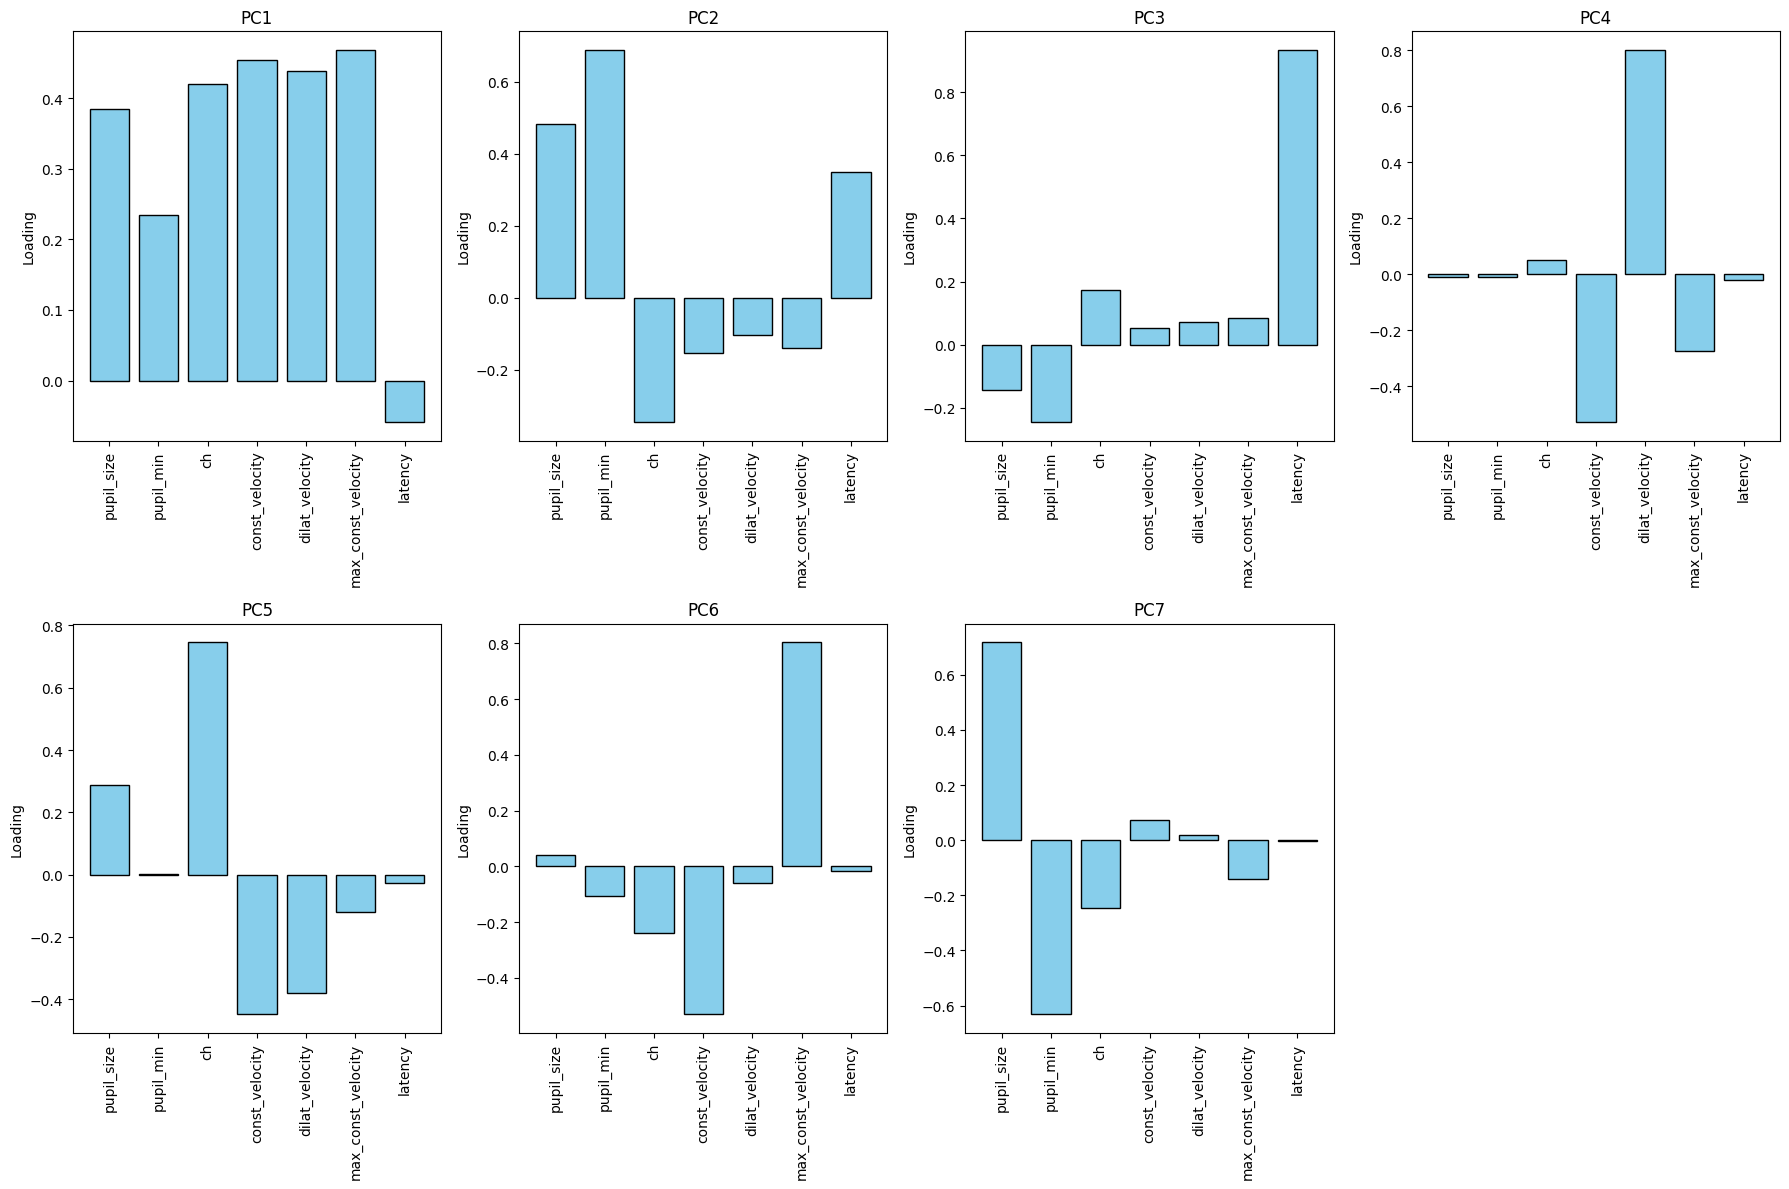

In [16]:
# Number of PCs to plot for NPI
n_pcs = 7
pcs_to_plot = [f"PC{i+1}" for i in range(n_pcs)]

plt.figure(figsize=(18, 12))

for i, pc in enumerate(pcs_to_plot, 1):
    plt.subplot(2, 4,i)  # 2 rows, 3 columns of subplots
    plt.bar(df_npi.columns,NPI_loadings[pc], color='skyblue', edgecolor='black')
    plt.xticks(rotation=90)
    plt.ylabel("Loading")
    plt.title(pc)

plt.tight_layout()
plt.show()